In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score)


In [2]:
df = pd.read_csv(r"C:/Users/elsay/OneDrive/Desktop/SLA ML/feature_engineered_data.csv")

In [3]:
leaky_cols = [
    'shipment_id', 
    'actual_delivery_days', 
    'delivery_delay_days', 
    'is_early_delivery', 
    'is_on_time', 
    'severe_delay_flag', 
    'delay_ratio', 
    'customs_delay_flag', 
    'weather_disruption_flag', 
    'any_disruption_flag', 
    'disruption_score'
]


In [4]:
X = df.drop(columns=['sla_breach_flag'] + [c for c in leaky_cols if c in df.columns])

In [5]:
X = X.select_dtypes(exclude=['object'])
y = df['sla_breach_flag']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=5000)
svm_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [9]:
y_pred = svm_model.predict(X_test_scaled)
y_scores = svm_model.decision_function(X_test_scaled)

In [10]:
print("--- REAL Model Performance () ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f} ()")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_scores):.4f}")

--- REAL Model Performance () ---
Accuracy:  0.8290
Recall:    0.7949 ()
ROC-AUC:   0.9382


In [11]:
coeffs = svm_model.coef_[0]
importance = pd.Series(coeffs, index=X.columns).sort_values(ascending=False)
print("\n--- Top 5 Features Predicting SLA Breach ---")
print(importance.head(5))


--- Top 5 Features Predicting SLA Breach ---
high_cost_but_high_delay    3.438031
priority_but_high_delay     1.052078
shipment_value_usd          0.387960
fragile_flag                0.125534
shipment_weight_kg          0.118667
dtype: float64


In [12]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84     20802
           1       0.84      0.79      0.81     18618

    accuracy                           0.83     39420
   macro avg       0.83      0.83      0.83     39420
weighted avg       0.83      0.83      0.83     39420



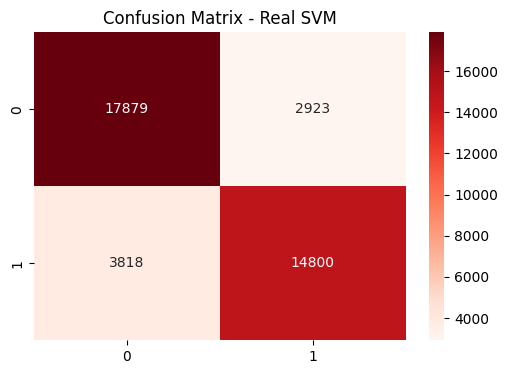

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Real SVM')
plt.show()

C:\Users\elsay\AppData\Local\Temp\ipykernel_4232\3095603125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.values, y=top_5.index, palette='magma')


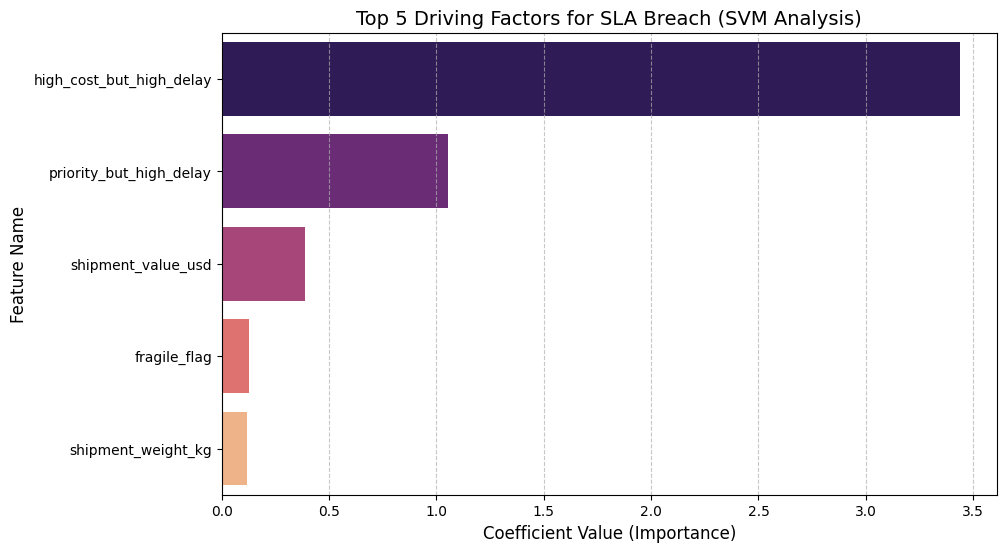

In [14]:
top_5 = importance.head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5.values, y=top_5.index, palette='magma')
plt.title('Top 5 Driving Factors for SLA Breach (SVM Analysis)', fontsize=14)
plt.xlabel('Coefficient Value (Importance)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [15]:
import joblib

# حفظ الموديل
joblib.dump(svm_model, "sla_svm_model.pkl")

# حفظ ال scaler
joblib.dump(scaler, "scaler.pkl")

# حفظ أسماء الفيتشرز
joblib.dump(X.columns.tolist(), "features.pkl")

print("Files saved successfully")

Files saved successfully
